In [1]:
import sys
from pathlib import Path
from tqdm.auto import tqdm
import yaml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

torch.set_default_dtype(torch.float64)

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (
    (repo_root / "benchmarks" / "01_main.py").exists()
    and (repo_root / "benchmarks" / "02_evaluate.py").exists()
    and (repo_root / "src" / "genkit").exists()
):
    repo_root = repo_root.parent

for path_entry in [repo_root, repo_root / "src"]:
    if str(path_entry) not in sys.path:
        sys.path.insert(0, str(path_entry))

from genkit.inspect import model_est_err_curve, model_est_jacobian_spectral_curve
from labkit.report import PRETTY_RCPARAMS, format_mean_std_latex
import importlib
_bench_eval = importlib.import_module("benchmarks.02_evaluate")
available_checkpoint_epochs = _bench_eval.available_checkpoint_epochs
load_generator_and_data = _bench_eval.load_generator_and_data


/home/hcherkaoui/src/flowbench/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.rcParams.update(PRETTY_RCPARAMS)

# BASELINE_DIR = repo_root / "benchmarks" / "data" / "256566_01_alphastable_baseline_preprocessed"
BASELINE_DIR = repo_root / "benchmarks" / "data" / "256567_02_hrrr_unet_preprocessed"
PREFERRED_LABELS = ["GF-Linear", "GF-OT", "DDPM-V", "DLPM", "TEDM-Orig"]
DISPLAY_MODEL_LABELS = {
    "gaussian_flow_linear": "GF-Linear",
    "gaussian_flow_ot": "GF-OT",
    "ddpm_v": "DDPM-V",
    "dlpm_eps": "DLPM",
    "tedm_origin": "TEDM-Orig",
}
MODEL_COLORS = {
    "GF-Linear": "tab:blue",
    "GF-OT": "tab:pink",
    "DDPM-V": "tab:green",
    "DLPM": "tab:orange",
    "TEDM-Orig": "tab:olive",
}
PERF_METRICS = ["FID", "MMD_RBF", "SLICED_WASSERSTEIN", "TAIL_COVERAGE_ERROR", "MSSLE"]
METRIC_LABELS = {
    "FID": "FID",
    "MMD_RBF": "MMD RBF",
    "SLICED_WASSERSTEIN": "Sliced Wasserstein",
    "TAIL_COVERAGE_ERROR": "Tail coverage error",
    "MSSLE": "MSSLE",
}


In [3]:
def ordered_labels(labels):
    """Return labels in the preferred display order, then sort the rest."""
    labels = list(dict.fromkeys(labels))
    return [label for label in PREFERRED_LABELS if label in labels] + sorted(
        label for label in labels if label not in PREFERRED_LABELS
    )


def load_batch_scalars(batch_dir: Path) -> pd.DataFrame:
    frames = []
    for run_dir in sorted(path for path in batch_dir.iterdir() if path.is_dir()):
        path = run_dir / "scalars.csv.gz"
        if not path.exists():
            path = run_dir / "eval" / "scalars.csv.gz"
        if path.exists():
            frames.append(pd.read_csv(path))
    if not frames:
        raise FileNotFoundError(f"No scalars.csv.gz found under {batch_dir}")
    frame = pd.concat(frames, ignore_index=True)
    for column in ["dataset_alpha", "model_alpha", "value", "checkpoint_epoch", "epoch"]:
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


def summarize_source_metrics(frame: pd.DataFrame, source: str, group_cols: list[str]) -> pd.DataFrame:
    summary = (
        frame[frame["source"].eq(source)]
        .groupby(group_cols + ["metric_name"], dropna=False)["value"]
        .agg(mean="mean", median="median", std=lambda s: float(s.std(ddof=0)))
        .reset_index()
    )
    summary["std"] = summary["std"].fillna(0.0)
    return summary


def best_parameter_rows(summary: pd.DataFrame, metric_name: str, fixed_cols: list[str]) -> pd.DataFrame:
    sub = summary[summary["metric_name"].eq(metric_name)].dropna(subset=["median"]).copy()
    if sub.empty:
        return sub
    rows = []
    for _, group in sub.groupby(fixed_cols, dropna=False):
        if "model_alpha" in group.columns and not group["model_alpha"].isna().all():
            rows.append(group.nsmallest(1, "median").iloc[0].to_dict())
        else:
            rows.append(group.iloc[0].to_dict())
    return pd.DataFrame(rows)


def safe_inspect_curve(curve_fn, generator, x, **kwargs):
    try:
        return np.asarray(curve_fn(generator, x, **kwargs), dtype=float)
    except ValueError as exc:
        if "can only inspect" not in str(exc).lower():
            raise
        return None


def plot_time_curve_panels(curves_by_epoch, models, checkpoint_epochs, titles, ylabel, *, yscale=None):
    fig, axes = plt.subplots(1, len(checkpoint_epochs), figsize=(2.4 * len(checkpoint_epochs), 2.2), sharex=True, sharey=True)
    axes = [axes] if len(checkpoint_epochs) == 1 else list(axes)

    for ax, checkpoint_epoch, title in zip(axes, checkpoint_epochs, titles):
        for model_label in models:
            values_list = curves_by_epoch[checkpoint_epoch][model_label]

            if not values_list:
                continue

            values = np.stack(values_list, axis=0)
            x_values = np.arange(values.shape[1])
            ax.plot(x_values, np.median(values, axis=0), linewidth=2.2, label=model_label, alpha=0.7, color=MODEL_COLORS.get(model_label, "tab:gray"))

        ax.set_title(title)
        ax.set_xlabel("Time trajectory (data->noise)")

        ax.set_xticks([0, x_values[-1]], ["data", "noise"])
        ax.set_yscale('log')
        ax.grid(alpha=0.2)

    axes[0].set_ylabel(ylabel)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False)

    fig.tight_layout(rect=(0, 0, 1, 0.88))
    plt.show()


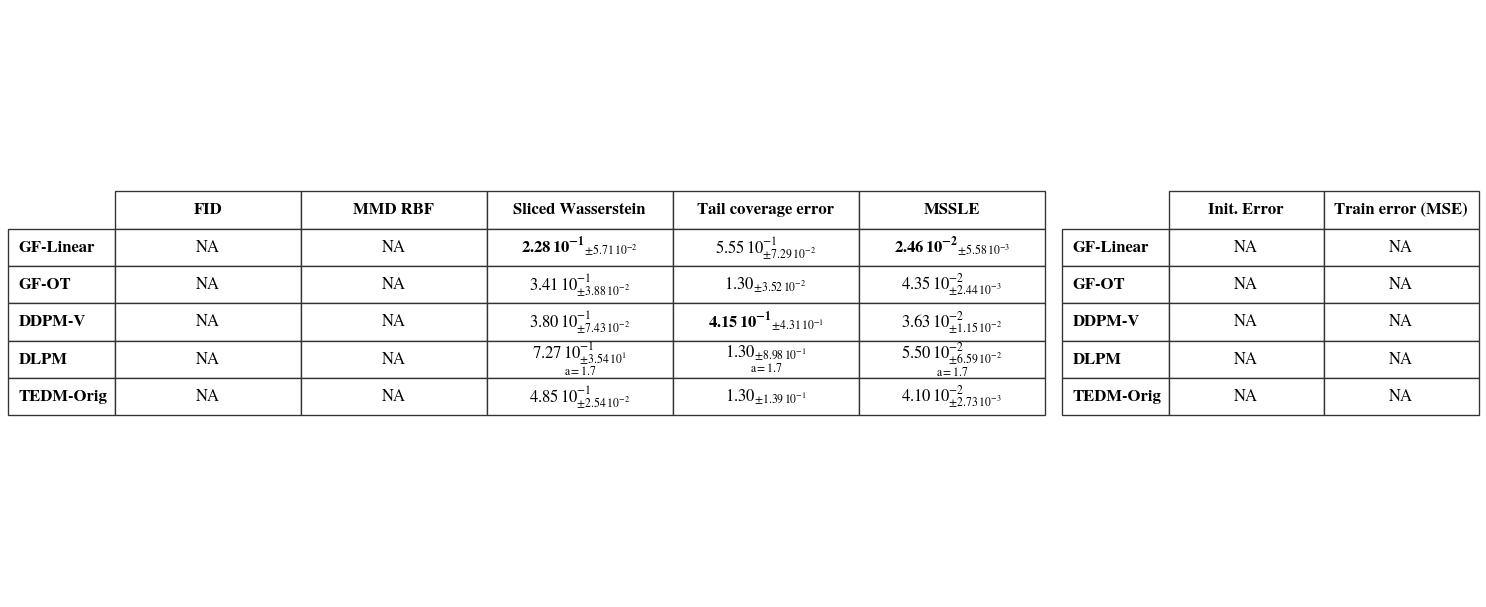

In [4]:
baseline_scalars = load_batch_scalars(BASELINE_DIR)
baseline_scalars["model_label"] = baseline_scalars["model_label"].replace(DISPLAY_MODEL_LABELS)
baseline_summary = summarize_source_metrics(baseline_scalars, "test_metrics", ["model_label", "model_alpha"])
row_labels = ordered_labels(baseline_summary["model_label"].dropna().unique())
baseline_table = pd.DataFrame("NA", index=row_labels, columns=[METRIC_LABELS[name] for name in PERF_METRICS], dtype=object)

for metric_name in PERF_METRICS:
    winners = best_parameter_rows(baseline_summary, metric_name, ["model_label"])
    if winners.empty:
        continue
    col_name = METRIC_LABELS[metric_name]
    best_label = winners.loc[winners["median"].idxmin(), "model_label"]
    for _, row in winners.iterrows():
        baseline_table.loc[row["model_label"], col_name] = format_mean_std_latex(
            row["median"],
            row["std"],
            caption="" if pd.isna(row.get("model_alpha")) else f"a={float(row.get("model_alpha")):.3g}",
            bold=row["model_label"] == best_label,
        )

inspect_summary = summarize_source_metrics(baseline_scalars, "inspect", ["model_label"])
inspect_metrics = ["init_error", "training_loss_error"]
inspect_labels = {
    "init_error": "Init. Error",
    "training_loss_error": "Train error (MSE)",
}
inspect_table = pd.DataFrame("NA", index=row_labels, columns=[inspect_labels[name] for name in inspect_metrics], dtype=object)

for metric_name in inspect_metrics:
    metric_df = inspect_summary[inspect_summary["metric_name"].eq(metric_name)].set_index("model_label")

    if metric_df.empty:
        continue

    ranking = metric_df["median"].dropna()
    ranking = ranking.clip(lower=1e-12) if metric_name == "init_error" else ranking
    if ranking.empty:
        continue
    best_label = ranking.idxmin()
    col_name = inspect_labels[metric_name]

    for model_label in row_labels:
        if model_label not in metric_df.index:
            continue

        stats = metric_df.loc[model_label]
        median = float(stats["median"])
        std = float(stats["std"])

        if not np.isfinite(median):
            continue

        display_median = max(1e-12, median) if metric_name == "init_error" else median
        inspect_table.loc[model_label, col_name] = format_mean_std_latex(display_median, 0.0 if not np.isfinite(std) else std, bold=model_label == best_label)

fig, (ax, inspect_ax) = plt.subplots(1, 2, gridspec_kw={"width_ratios": [3, 1]}, figsize=(11.0, 1.3 + 0.7 * len(baseline_table.index)))

ax.axis("off")
mpl_table = ax.table(cellText=baseline_table.values, rowLabels=list(baseline_table.index), colLabels=list(baseline_table.columns), loc="center", cellLoc="center")
mpl_table.auto_set_font_size(False)
mpl_table.set_fontsize(7.5)
mpl_table.scale(1.0, 1.4)

for (row, col), cell in mpl_table.get_celld().items():
    cell.set_edgecolor("0.2")
    cell.set_linewidth(0.6)
    if row == 0 or col == -1:
        cell.set_text_props(weight="bold")

inspect_ax.axis("off")
inspect_mpl_table = inspect_ax.table(cellText=inspect_table.values, rowLabels=list(inspect_table.index), colLabels=list(inspect_table.columns), loc="center", cellLoc="center")
inspect_mpl_table.auto_set_font_size(False)
inspect_mpl_table.set_fontsize(7.5)
inspect_mpl_table.scale(1.0, 1.4)

for (row, col), cell in inspect_mpl_table.get_celld().items():
    cell.set_edgecolor("0.2")
    cell.set_linewidth(0.6)
    if row == 0 or col == -1:
        cell.set_text_props(weight="bold")

plt.show()

/tmp/ipykernel_248995/3651812482.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.92))


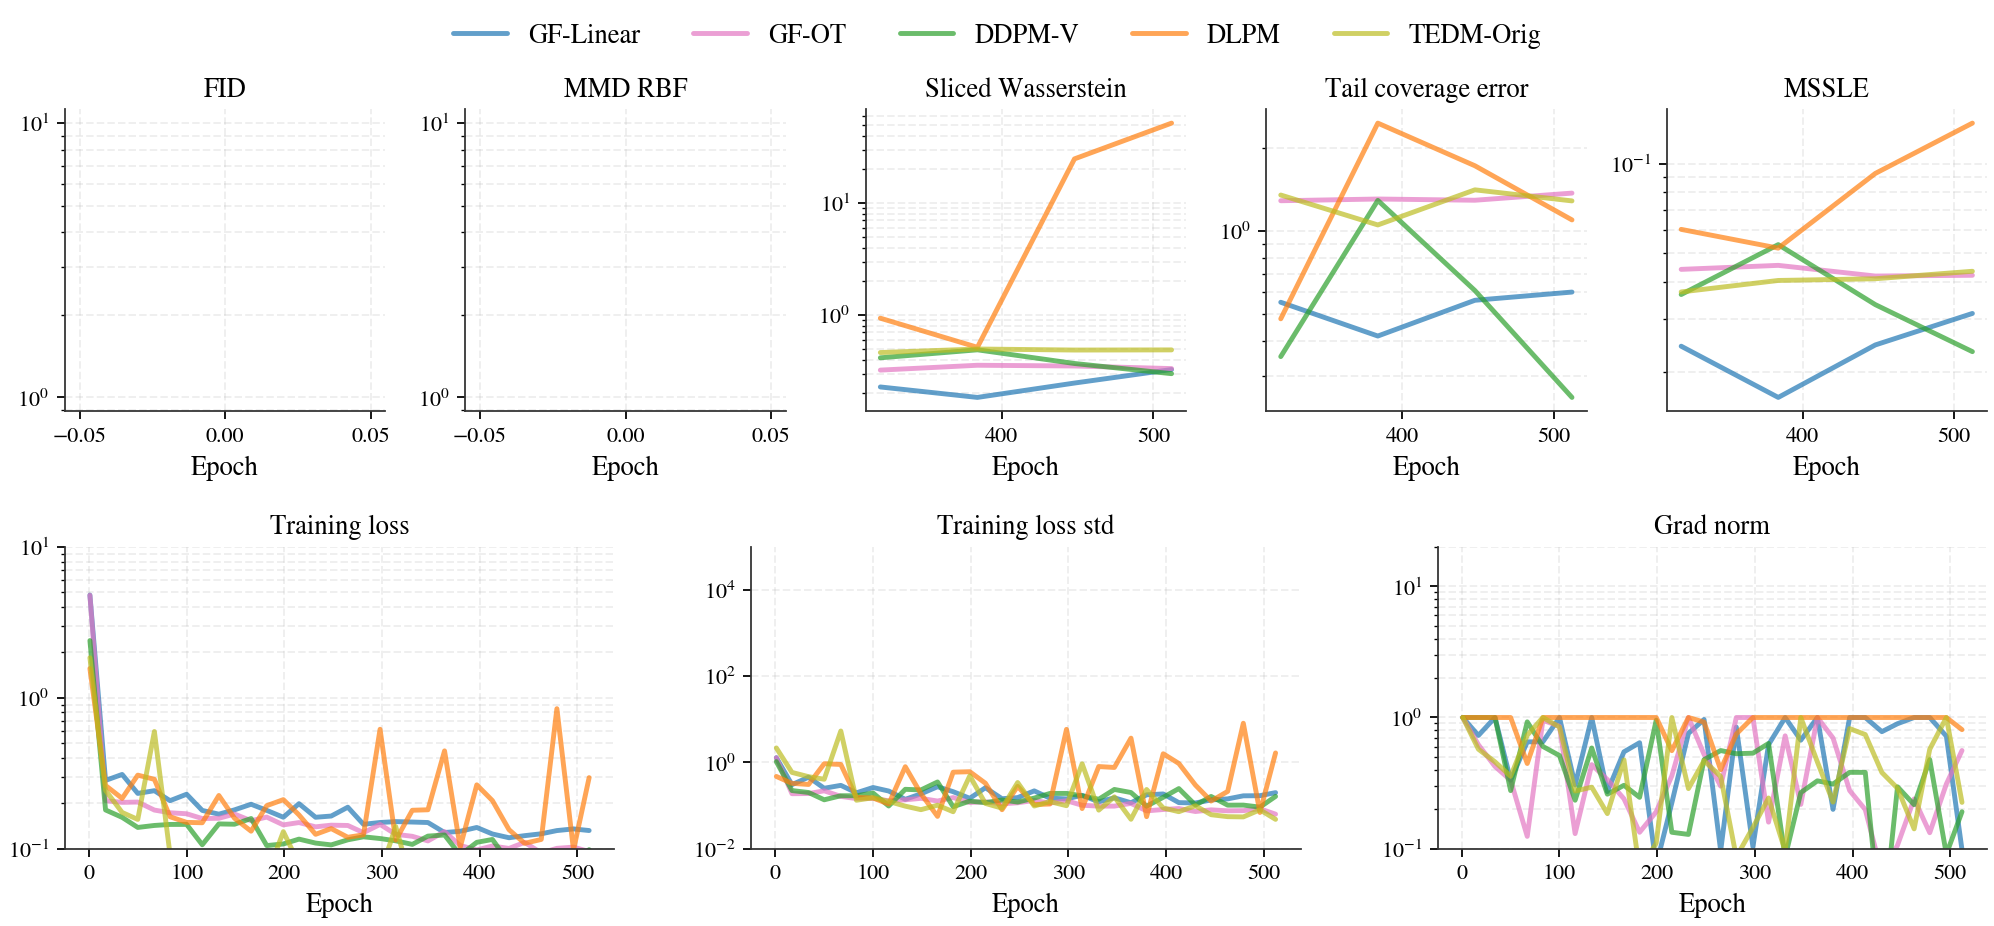

In [8]:
evolution = summarize_source_metrics(baseline_scalars, "test_metrics", ["checkpoint_epoch", "model_label"])
models = ordered_labels(evolution["model_label"].dropna().unique())
metric_ylims = {
    "FID": (1e2, 1e9),
    "MMD_RBF": (1e-4, 5e-2),
    "SLICED_WASSERSTEIN": (1e0, 1e10),
    "TAIL_COVERAGE_ERROR": (5e-1, 1e1),
    "MSSLE": (1e-3, 1e0),
}

train_evolution = summarize_source_metrics(baseline_scalars, "train_stats", ["epoch", "model_label"])
train_models = ordered_labels(train_evolution["model_label"].dropna().unique())
train_metrics = ["training_loss", "training_loss_std", "grad_norm_epoch"]
train_metric_labels = {
    "training_loss": "Training loss",
    "training_loss_std": "Training loss std",
    "grad_norm_epoch": "Grad norm",
}
train_metric_ylims = {
    "training_loss": (1e-1, 1e1),
    "training_loss_std": (1e-2, 1e5),
    "grad_norm_epoch": (1e-1, 2e1),
}
max_train_points = 32

fig = plt.figure(figsize=(3.1 * max(len(PERF_METRICS), len(train_metrics)), 6.0))
outer = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.45)

metric_grid = outer[0].subgridspec(1, len(PERF_METRICS), wspace=0.25)
metric_axes = [fig.add_subplot(metric_grid[0, idx]) for idx in range(len(PERF_METRICS))]

for ax, metric_name in zip(metric_axes, PERF_METRICS):
    sub = evolution[evolution["metric_name"].eq(metric_name)]
    for model_label in models:
        curve = sub[sub["model_label"].eq(model_label)].sort_values("checkpoint_epoch")
        if curve.empty:
            continue
        ax.plot(curve["checkpoint_epoch"], curve["median"], linewidth=2.2, label=model_label, alpha=0.7, color=MODEL_COLORS.get(model_label, "tab:gray"))
    ax.set_yscale("log")
    # ax.set_ylim(*metric_ylims[metric_name])
    ax.set_title(METRIC_LABELS[metric_name])
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.2, which="both")

train_grid = outer[1].subgridspec(1, len(train_metrics), wspace=0.25)
train_axes = [fig.add_subplot(train_grid[0, idx]) for idx in range(len(train_metrics))]

for ax, metric_name in zip(train_axes, train_metrics):
    sub = train_evolution[train_evolution["metric_name"].eq(metric_name)]
    for model_label in train_models:
        curve = sub[sub["model_label"].eq(model_label)].sort_values("epoch")

        if curve.empty:
            continue

        if len(curve) > max_train_points:
            sample_idx = np.unique(np.round(np.linspace(0, len(curve) - 1, num=max_train_points)).astype(int))
            curve = curve.iloc[sample_idx]

        ax.plot(curve["epoch"], curve["median"], linewidth=2.2, label=model_label, alpha=0.7, color=MODEL_COLORS.get(model_label, "tab:gray"))

    ax.set_yscale("log")
    ax.set_ylim(*train_metric_ylims[metric_name])
    ax.set_title(train_metric_labels[metric_name])
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.2, which="both")

legend_handles = {}
for ax in metric_axes + train_axes:
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        legend_handles.setdefault(label, handle)

legend_labels = ordered_labels(set(models).union(train_models))
handles = [legend_handles[label] for label in legend_labels if label in legend_handles]
labels = [label for label in legend_labels if label in legend_handles]
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False)

fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()


In [6]:
raw_baseline_dir = BASELINE_DIR.with_name(BASELINE_DIR.name.removesuffix("_preprocessed"))
run_dirs = sorted(path for path in raw_baseline_dir.iterdir() if path.is_dir())
checkpoint_epochs = available_checkpoint_epochs(run_dirs[0])
middle_idx = (len(checkpoint_epochs) - 1) // 2
selected_epochs = [checkpoint_epochs[0], checkpoint_epochs[middle_idx], checkpoint_epochs[-1]]
panel_titles = ["First epoch ", "Mid epoch", "Last epoch"]

supported_model_names = {"ddpm_v", "dlpm_eps", "gaussian_flow_linear", "gaussian_flow_ot"}
run_entries = []
for run_dir in run_dirs:
    config = yaml.safe_load((run_dir / "config.yaml").read_text())
    model_name = config["model"]["name"]
    if model_name in supported_model_names and (run_dir / "checkpoint.pt").exists():
        run_entries.append((DISPLAY_MODEL_LABELS.get(model_name, model_name), run_dir))

jacobian_models = ordered_labels({model_label for model_label, _ in run_entries})
runs_by_model = {
    model_label: [run_dir for other_model_label, run_dir in run_entries if other_model_label == model_label]
    for model_label in jacobian_models
}

max_trials_per_model = 5
probe_size = 16
power_iter = 8
max_steps = 16

curves = {epoch: {model_label: [] for model_label in jacobian_models} for epoch in selected_epochs}
score_err_curves = {epoch: {model_label: [] for model_label in jacobian_models} for epoch in selected_epochs}
tasks = [(model_label, run_dir) for model_label in jacobian_models
         for run_dir in runs_by_model[model_label][:max_trials_per_model]]

with tqdm(total=len(tasks), desc="Time curves") as pbar:
    for idx, (model_label, run_dir) in enumerate(tasks, start=1):
        config = yaml.safe_load((run_dir / "config.yaml").read_text())
        final_epoch = int(config["train"]["n_epochs"])

        for checkpoint_epoch in selected_epochs:
            try:
                generator, _, x_test, _, _ = load_generator_and_data(
                    run_dir,
                    device="cpu",
                    checkpoint_epoch=None if checkpoint_epoch == final_epoch else checkpoint_epoch,
                )
            except FileNotFoundError:
                continue

            x_probe = x_test[:probe_size, :]
            jacobian_curve = safe_inspect_curve(model_est_jacobian_spectral_curve, generator,
                                                x_probe, n_power_iter=power_iter,
                                                max_n_steps=max_steps)
            score_curve = safe_inspect_curve(model_est_err_curve, generator,
                                             x_probe, loss_type="mse",
                                             max_n_steps=max_steps)

            curves[checkpoint_epoch][model_label].append(jacobian_curve)
            score_err_curves[checkpoint_epoch][model_label].append(score_curve)

        pbar.update(1)
        pbar.set_postfix(model=model_label)


Time curves:   0%|          | 0/4 [00:00<?, ?it/s]


RuntimeError: HRRR loader requires wgrib2.

In [ ]:
plot_time_curve_panels(curves, jacobian_models, selected_epochs, panel_titles, "Jac. spectral norm")


In [ ]:
plot_time_curve_panels(score_err_curves, jacobian_models, selected_epochs, panel_titles, "'Score' est. error")
